In [21]:
# Importing libraries
import pandas as pd
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler 
import warnings
warnings.filterwarnings('ignore')
import scipy
from sklearn.cluster import KMeans
from PIL import Image
import statsmodels.api
from itertools import combinations

In [22]:
# Importing coordinates
local = pd.read_csv(r"C:\Users\joaoa\Desktop\Doutoramento\Professora\Nova pasta\Todos os Pontos (temperatura)\local.cvs")

# Defining parameters
min_corr = 0.6 # 0.6
perc = 0.8
Y = range(1950, 2023) # 1950-2023
T = ["no restriction", "9h-9h"]
H = [1,2,4,6,12,24,48,96] # [1,2,3,4,6,8,12,24,48,72,96,120]

In [23]:
max_precipitations = pd.read_csv(r"D:\Precipitation\by_water_year\max_precipitations_(mm).csv")
max_precipitations

,year,type_of_period,duration,P0000,P0001,P0002,P0003,P0004,P0005,P0006,...,P1047,P1048,P1055,P1056,P1057,P1058,P1059,P1062,P1063,P1064
0,1950_1951,no restriction,1h,8.326463,8.243036,8.805152,9.028085,9.084161,8.476909,7.380027,...,3.436994,3.357664,3.744721,3.943034,3.918417,3.777545,3.583334,4.295899,4.206998,4.134510
1,1950_1951,no restriction,2h,15.106078,16.101751,16.759608,16.780123,16.432732,15.006237,13.470327,...,6.239377,5.898822,7.132474,7.441573,7.321216,7.192655,7.053152,8.147297,7.940779,7.769816
2,1950_1951,no restriction,3h,20.434577,22.103149,22.261806,21.800894,22.388998,21.266129,19.032700,...,7.886067,8.359287,10.383461,10.725383,10.626908,10.405345,10.334227,11.299809,11.242369,11.195865
3,1950_1951,no restriction,4h,23.979615,25.218735,26.281431,26.591893,26.449654,24.742782,22.127772,...,8.817460,9.966318,14.006458,14.470104,13.779424,13.340397,13.321247,14.879042,14.202038,13.961323
4,1950_1951,no restriction,6h,27.777676,29.959129,30.581430,30.573227,30.292848,28.803440,26.464701,...,9.726975,12.720834,19.964095,20.419532,19.537376,18.939698,18.073954,21.215523,20.230791,19.408811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1747,2022_2023,9h-9h,24h,54.779407,84.152669,78.163899,69.087140,61.068974,52.875238,47.976034,...,33.152206,27.432676,23.512300,24.586378,25.095019,25.851524,27.461352,29.078925,29.064724,29.050523
1748,2022_2023,9h-9h,48h,87.853795,110.887036,107.861828,103.527183,96.785700,88.935407,80.281787,...,38.806304,32.095753,46.217747,48.270375,49.124993,49.509700,50.263621,50.270073,50.356567,50.426278
1749,2022_2023,9h-9h,72h,94.963124,117.144329,117.125774,116.913173,110.899793,101.122091,88.095980,...,38.814284,32.113306,47.071073,49.186960,50.157759,50.774843,51.829558,51.357064,51.497780,51.613968
1750,2022_2023,9h-9h,96h,114.451494,142.719587,142.209170,141.910078,135.120828,124.048291,109.234199,...,45.058457,43.492522,67.695491,71.006805,73.210482,74.905513,76.910375,76.315241,77.277005,78.081276


In [24]:
# Collecting all information in one dictionary
dict_max = {"no restriction" : {}, "9h-9h" : {}}

for type_of_period in T: 
    for hours in H:
        dict_max[type_of_period][str(hours) + "h"] = max_precipitations[(max_precipitations["type_of_period"] == type_of_period) & (max_precipitations["duration"] == str(hours) + "h")].iloc[:, 3:].reset_index(drop = True)

In [25]:
seq_clusters = {"no restriction" : pd.DataFrame(), "9h-9h" : pd.DataFrame()}
n_clusters = {"no restriction" : 0, "9h-9h" : 0}


for t in T:

    for h in H:
        df = dict_max[t][str(h) + "h"]

        # Standardizing dataframe
        scaler = StandardScaler() 
        variables = scaler.fit_transform(df) 
        variables = pd.DataFrame(variables, columns = df.columns)
        variables = variables*np.sqrt((len(variables)-1)/len(variables))
        var_list = variables.columns

        # Transposing dataframe
        transp = variables.transpose()

        # Clustering (PCA)
        pca = PCA(perc)
        scores = pca.fit_transform(variables.values)
        print("Time type: " + t + " | Time interval: " + str(h) + "h | Clusters: " + str(len(pca.explained_variance_)) + " | Explained variance: " + str(round(sum(pca.explained_variance_ratio_)*100,1)) + " %")
        
        if h == 1:
            n_clusters[t] = len(pca.explained_variance_)
        
        comp_list = []
        comp_list_num = []
        for i in range(1, len(pca.explained_variance_)+1):
            comp_list.append("PC_" + str(i))
            comp_list_num.append(str(i))

        scores = pd.DataFrame(scores, columns = comp_list)
        eigenvalues = pd.DataFrame(pca.explained_variance_, index = comp_list, columns = ["explained variance"])
        eigenvectors = pd.DataFrame(np.transpose(pca.components_), index = var_list, columns = comp_list)
        loadings = pd.DataFrame(index = var_list, columns = comp_list)
        for col in range(0,len(loadings.columns)):
            loadings.iloc[:,col] = eigenvectors.iloc[:,col]*np.sqrt(eigenvalues.values[col])
        rotated_loadings = pd.DataFrame(statsmodels.multivariate.factor_rotation.rotate_factors(loadings.values, "varimax")[0], index = var_list, columns = comp_list_num)
        rotated_loadings = abs(rotated_loadings)
        rotated_loadings["max"] = rotated_loadings.max(axis = 1)
        rotated_loadings["cluster"] = rotated_loadings.iloc[:,:-1].idxmax(axis=1)
        rotated_loadings.loc[rotated_loadings["max"] < min_corr, "cluster"] = "z"
        transp[str(h) + "h (" + t + ")"] = rotated_loadings["cluster"]           

        # Concatenating clusters   
        seq_clusters[t] = pd.concat([seq_clusters[t], transp.iloc[:,-1]], axis = 1)


    # Creating a final column with sequence
    seq_clusters[t] = seq_clusters[t].astype(str)

    i = 0
    seq_clusters[t]["code"] = ""
    for h in H:
        seq_clusters[t]["code"] = seq_clusters[t]["code"] + seq_clusters[t].iloc[:,i]
        i += 1

Time type: no restriction | Time interval: 1h | Clusters: 13 | Explained variance: 80.8 %
Time type: no restriction | Time interval: 2h | Clusters: 11 | Explained variance: 80.1 %
Time type: no restriction | Time interval: 4h | Clusters: 11 | Explained variance: 80.7 %
Time type: no restriction | Time interval: 6h | Clusters: 11 | Explained variance: 81.3 %
Time type: no restriction | Time interval: 12h | Clusters: 9 | Explained variance: 80.4 %
Time type: no restriction | Time interval: 24h | Clusters: 7 | Explained variance: 80.6 %
Time type: no restriction | Time interval: 48h | Clusters: 6 | Explained variance: 80.1 %
Time type: no restriction | Time interval: 96h | Clusters: 4 | Explained variance: 81.2 %
Time type: 9h-9h | Time interval: 1h | Clusters: 13 | Explained variance: 80.8 %
Time type: 9h-9h | Time interval: 2h | Clusters: 11 | Explained variance: 80.0 %
Time type: 9h-9h | Time interval: 4h | Clusters: 11 | Explained variance: 80.9 %
Time type: 9h-9h | Time interval: 6h 

In [26]:
seq_clusters["no restriction"]

,1h (no restriction),2h (no restriction),4h (no restriction),6h (no restriction),12h (no restriction),24h (no restriction),48h (no restriction),96h (no restriction),code
P0000,3,10,5,5,2,2,2,2,310552222
P0001,3,10,5,5,2,2,2,2,310552222
P0002,3,10,5,5,2,2,2,2,310552222
P0003,3,10,5,5,2,2,2,2,310552222
P0004,3,10,5,5,2,2,2,2,310552222
...,...,...,...,...,...,...,...,...,...
P1058,6,6,6,8,8,4,3,3,66688433
P1059,6,6,6,8,8,4,3,3,66688433
P1062,6,6,6,8,8,4,3,3,66688433
P1063,6,6,6,8,8,4,3,3,66688433


In [27]:
codes = seq_clusters["no restriction"].groupby("code")["code"].agg("count").sort_values(ascending = False)
codes = codes[~codes.index.str.contains("z")]
codes = codes[0:n_clusters["no restriction"]]
codes

code
22345544      73
310552222     52
84994351      37
66688433      33
77821112      32
11117351      29
1351033433    22
11121112      15
11117311      15
53272222      13
11111111      13
1011745544    11
53271112       8
Name: code, dtype: int64

In [28]:
sum(codes)

353

In [29]:
# Deciding most frequent exclusive clusters 
commun_points = {"no restriction" : {}, "9h-9h" : {}}

for t in T:

    # Saving all codes with absolute frequency greater than or equal to 5
    i = 0
    codes = seq_clusters[t].groupby("code")["code"].agg("count").sort_values(ascending = False)
    codes = codes[~codes.index.str.contains("z")]
    codes = codes[0:n_clusters[t]]

    top_lista = []
    for _ in range(0,len(codes)):
        top_lista.append(codes.index[_])
    top_lista

    # Creating a commun column
    seq_clusters[t]["commun"] = "-1"

    for _ in range(0, len(top_lista)):
        seq_clusters[t].loc[seq_clusters[t]["code"] == top_lista[_], "commun"] = str(_)

    commun_points[t] = len(seq_clusters[t][seq_clusters[t]["commun"] != "-1"])

In [30]:
seq_clusters["no restriction"]

,1h (no restriction),2h (no restriction),4h (no restriction),6h (no restriction),12h (no restriction),24h (no restriction),48h (no restriction),96h (no restriction),code,commun
P0000,3,10,5,5,2,2,2,2,310552222,1
P0001,3,10,5,5,2,2,2,2,310552222,1
P0002,3,10,5,5,2,2,2,2,310552222,1
P0003,3,10,5,5,2,2,2,2,310552222,1
P0004,3,10,5,5,2,2,2,2,310552222,1
...,...,...,...,...,...,...,...,...,...,...
P1058,6,6,6,8,8,4,3,3,66688433,3
P1059,6,6,6,8,8,4,3,3,66688433,3
P1062,6,6,6,8,8,4,3,3,66688433,3
P1063,6,6,6,8,8,4,3,3,66688433,3


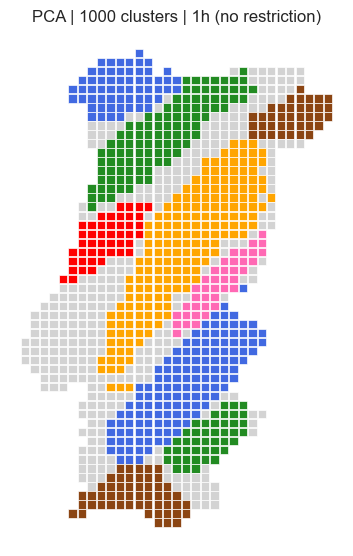

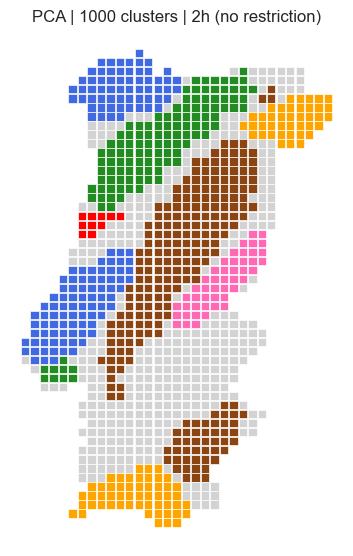

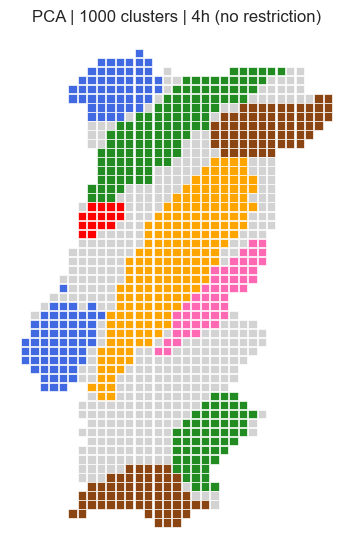

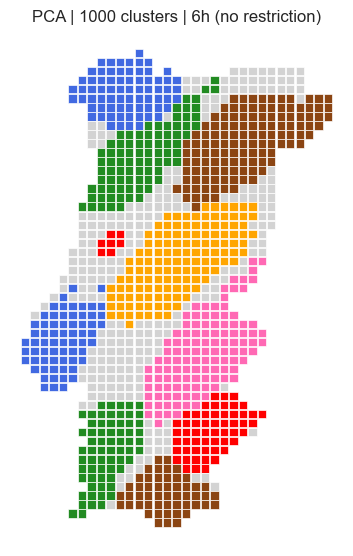

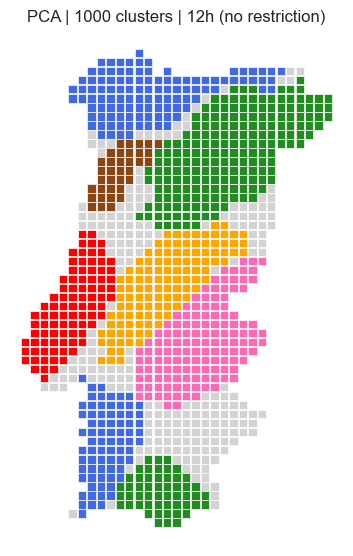

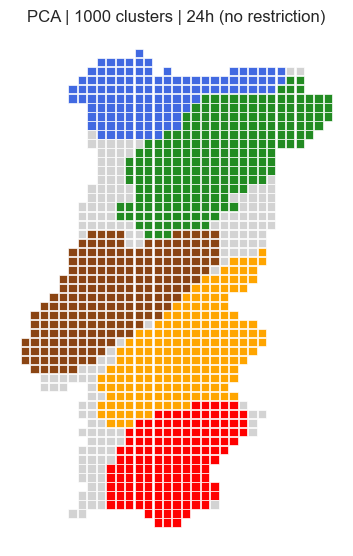

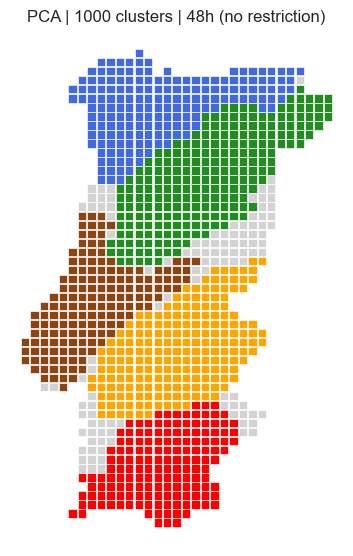

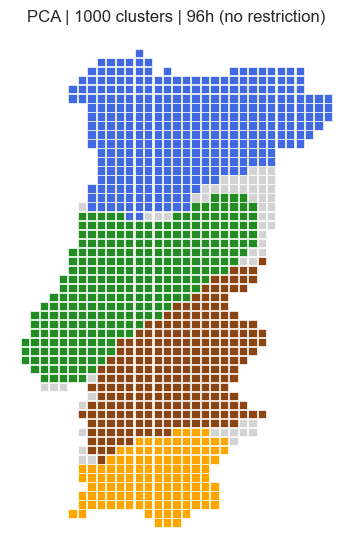

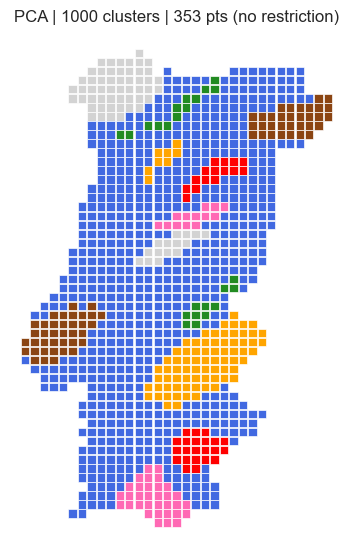

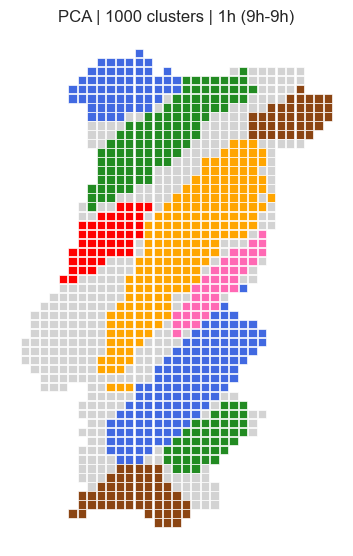

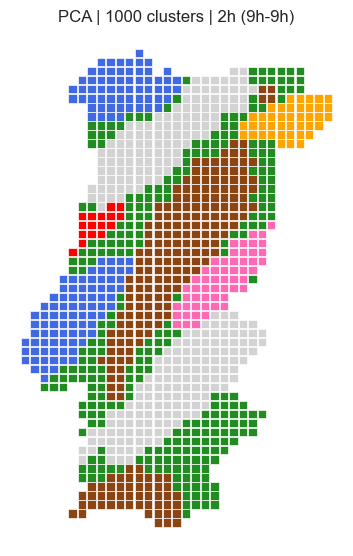

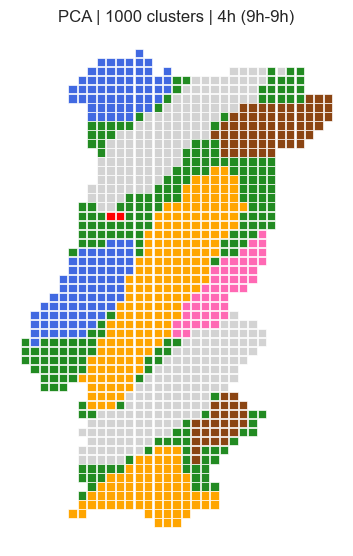

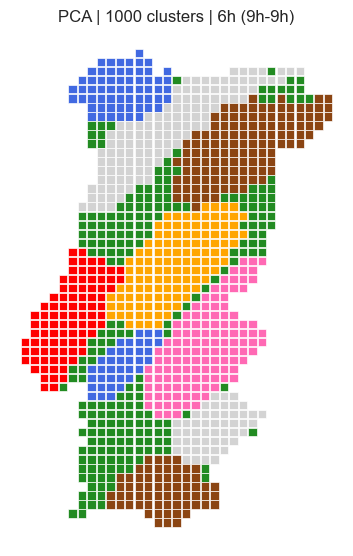

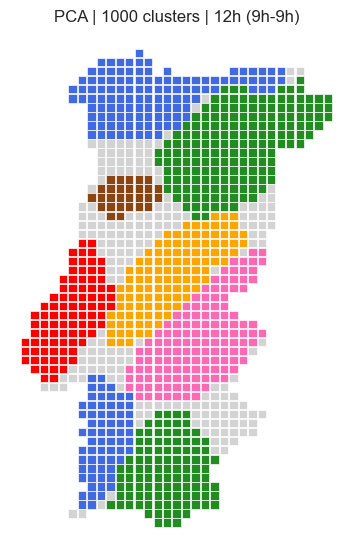

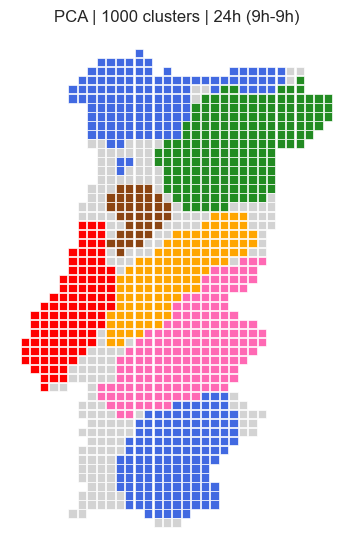

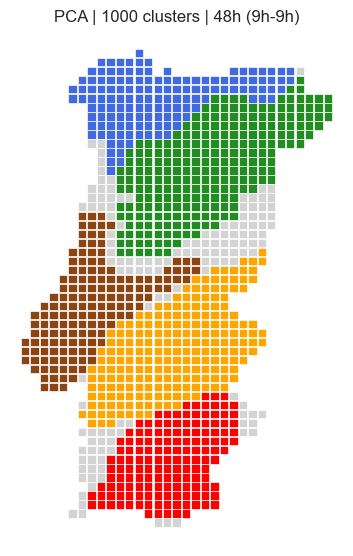

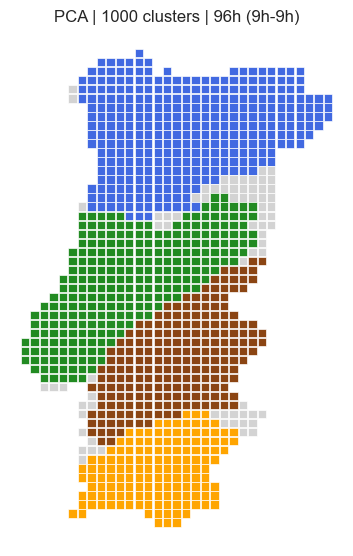

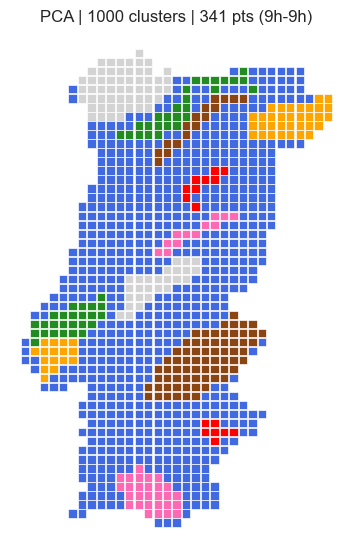

In [31]:
# Visualization
for t in T:
    n = 1000
    seq_clusters[t] = seq_clusters[t].reset_index(drop = True)
    df_plot = pd.concat([local, seq_clusters[t]], axis = 1)
                         
                         
    # Plotting clusters
    for h in H:

        palette_1 = ["royalblue", "lightgrey", "forestgreen", "saddlebrown", "orange", "red", "hotpink"]
        sns.set_theme(style = 'white')
        sns.relplot(data = df_plot, x = "longitude", y = "latitude", hue = str(h) + "h (" + t + ")", palette = palette_1, marker = "s", height = 6, aspect = 0.7, legend = False).set(title = "PCA | " + str(n) + " clusters" + " | " + str(h) + "h (" + t + ")")
        plt.axis("off")
        plt.savefig(r"C:\Users\joaoa\Desktop\plots\pca_" + str(n) + "_clusters_" + str(h) + "h_(" + t + ").png", bbox_inches = 'tight')
        plt.show()

    # Plotting commun area

    palette_2 = ["lightgrey", "royalblue", "forestgreen",  "saddlebrown", "orange", "red", "hotpink"]


    sns.set_theme(style = 'white')
    sns.relplot(data = df_plot, x = "longitude", y = "latitude", hue = "commun", palette = palette_2, marker = "s", height = 6, aspect = 0.7, legend = False).set(title = "PCA | " + str(n) + " clusters" + " | " + str(commun_points[t]) + " pts (" + t + ")")
    plt.axis("off")
    plt.savefig(r"C:\Users\joaoa\Desktop\plots\pca_" + str(n) + "_clusters_commun_(" + t + ").png", bbox_inches = 'tight')
    plt.show()

In [ ]:
for t in T:
    n = 1000
    seq_clusters[t] = seq_clusters[t].reset_index(drop = True)
    df_plot = pd.concat([local, seq_clusters[t]], axis = 1)

    fig = plt.figure(figsize = (55, 55))
    columns = len(H) + 1
    rows = 1
    i = 0

    for h in H:
        i += 1
        img = Image.open(r"C:\Users\joaoa\Desktop\plots\kmeans_" + str(n) + "_clusters_" + str(h) + "h_(" + t + ").png")
        fig.add_subplot(rows, columns, i)
        plt.subplots_adjust(wspace = 0, hspace = 0)
        plt.axis("off")
        plt.imshow(img)

    i += 1
    img = Image.open(r"C:\Users\joaoa\Desktop\plots\kmeans_" + str(n) + "_clusters_commun_(" + t + ").png")
    fig.add_subplot(rows, columns, i)
    plt.subplots_adjust(wspace = 0, hspace = 0)
    plt.axis("off")
    plt.imshow(img)

    print(str(n) + " clusters   |   " + t + "   |   Number of commun points:", commun_points[t])
    plt.savefig(r"C:\Users\joaoa\Desktop\plots\kmeans_" + str(n) + "_clusters_all_maps_(" + t + ").png", bbox_inches = 'tight')
    plt.show()